In [56]:
import jax 
import jax.numpy as jnp

import matplotlib.pyplot as plt

from probjax.utils.torchvision_datasets import MNIST, NumpyLoader

from probjax.distributions.divergences.wasserstein import wasserstein_distance, sliced_wasserstein_distance, max_slice_wasserstein_distance
from probjax.distributions.discrete import Empirical
from probjax.distributions.independent import Independent
from probjax.distributions import Uniform

from sklearn.manifold import MDS, Isomap, TSNE

In [57]:
def transform_data(x):
    # Uniformly quantize
    x = jnp.reshape(jnp.asarray(x, dtype=jnp.float32), (-1, 784))
    normed = x / 255.
    return normed

mnist_dataset = MNIST('/tmp/mnist/', download=True, transform=transform_data)
training_generator = NumpyLoader(mnist_dataset, batch_size=100, num_workers=0)

input_dim = 784

In [58]:

# Separate the datasets by label
datasets_per_num = [[] for _ in range(10)]
for i in range(len(mnist_dataset)):
    image, label = mnist_dataset[i]
    datasets_per_num[label].append(image)


In [59]:
samples_per_num = 5000
datasets_per_num = [jnp.squeeze(jnp.asarray(x))[:samples_per_num] for x in datasets_per_num]

In [60]:
p0 = Independent(Empirical(datasets_per_num[0]), 1)
p1 = Independent(Empirical(datasets_per_num[1]), 1)
p2 = Independent(Empirical(datasets_per_num[2]), 1)
p3 = Independent(Empirical(datasets_per_num[3]), 1)
p4 = Independent(Empirical(datasets_per_num[4]), 1)
p5 = Independent(Empirical(datasets_per_num[5]), 1)
p6 = Independent(Empirical(datasets_per_num[6]), 1)
p7 = Independent(Empirical(datasets_per_num[7]), 1)
p8 = Independent(Empirical(datasets_per_num[8]), 1)
p9 = Independent(Empirical(datasets_per_num[9]), 1)
p10 = Independent(Uniform(jnp.zeros((input_dim,)), jnp.ones((input_dim,))), 1)

distributions = [p0, p1, p2, p3, p4, p5, p6, p7, p8, p9, p10]

In [12]:
# distances_w2 = jnp.zeros((len(distributions), len(distributions)))
# key = jax.random.PRNGKey(0)
# for i in range(len(distributions)):
#     for j in range(i, len(distributions)):
#         key, subkey = jax.random.split(key)
#         distance_w2 = wasserstein_distance(distributions[i], distributions[j], mc_samples=400, key=key,  order=2., epsilon=0.1)
#         distances_w2 = distances_w2.at[i, j].set(distance_w2)
        
# # Normalize with self distance
# distances_w2 = distances_w2 - jnp.diag(distances_w2)[:, None]
# distances_w2 = jnp.triu(distances_w2) + jnp.triu(distances_w2, k=1).T

In [61]:
distances_w1 = jnp.zeros((len(distributions), len(distributions)))
key = jax.random.PRNGKey(0)
for i in range(len(distributions)):
    for j in range(i, len(distributions)):
        key, subkey = jax.random.split(key)
        distance_w1 = wasserstein_distance(distributions[i], distributions[j], mc_samples=400, key=key,  order=1., epsilon=0.1)
        distances_w1 = distances_w1.at[i, j].set(distance_w1)
        
# Normalize with self distance and symmetrize

distances_w1 = distances_w1 - jnp.diag(distances_w1)[:, None]
distances_w1 = jnp.triu(distances_w1) + jnp.triu(distances_w1, k=1).T

In [14]:
# distances_sliced_w1 = jnp.zeros((len(distributions), len(distributions)))
# key = jax.random.PRNGKey(0)
# for i in range(len(distributions)):
#     for j in range(i, len(distributions)):
#         key, subkey = jax.random.split(key)
#         distance_sliced_w1 = sliced_wasserstein_distance(distributions[i], distributions[j], mc_samples=5000, key=key,  num_slices=1000)
#         distances_sliced_w1 = distances_sliced_w1.at[i, j].set(distance_sliced_w1)
        
# # Normalize with self distance and symmetrize
# distances_sliced_w1 = distances_sliced_w1 - jnp.diag(distances_sliced_w1)[:, None]
# distances_sliced_w1 = jnp.triu(distances_sliced_w1) + jnp.triu(distances_sliced_w1, k=1).T

In [15]:
# distances_sliced_w1_more_slices = jnp.zeros((len(distributions), len(distributions)))
# key = jax.random.PRNGKey(0)
# for i in range(len(distributions)):
#     for j in range(i, len(distributions)):
#         key, subkey = jax.random.split(key)
#         distance_sliced_w1 = sliced_wasserstein_distance(distributions[i], distributions[j], mc_samples=5000, key=key,  num_slices=10000)
#         distances_sliced_w1_more_slices = distances_sliced_w1_more_slices.at[i, j].set(distance_sliced_w1)
        
# # Normalize with self distance and symmetrize
# distances_sliced_w1_more_slices = distances_sliced_w1_more_slices - jnp.diag(distances_sliced_w1_more_slices)[:, None]
# distances_sliced_w1_more_slices = jnp.triu(distances_sliced_w1_more_slices) + jnp.triu(distances_sliced_w1_more_slices, k=1).T

In [37]:
distances_sliced_w1_max_slices = jnp.zeros((len(distributions), len(distributions)))
key = jax.random.PRNGKey(0)
for i in range(len(distributions)):
    for j in range(i, len(distributions)):
        key, subkey = jax.random.split(key)
        distance_sliced_w1 = max_slice_wasserstein_distance(distributions[i], distributions[j], mc_samples=4000, key=jax.random.PRNGKey(i), tol=1e-2, num_init=10)
        distances_sliced_w1_max_slices = distances_sliced_w1_max_slices.at[i, j].set(distance_sliced_w1)
        
# Normalize with self distance and symmetrize
distances_sliced_w1_max_slices = distances_sliced_w1_max_slices - jnp.diag(distances_sliced_w1_max_slices)
distances_sliced_w1_max_slices = jnp.triu(distances_sliced_w1_max_slices) + jnp.triu(distances_sliced_w1_max_slices, k=1).T

In [64]:
jnp.save('data/distances_w1.npy', distances_w1)
# jnp.save('data/distances_w2.npy', distances_w2)
# jnp.save('data/distances_sliced_w1.npy', distances_sliced_w1)
# jnp.save('data/distances_sliced_w1_more_slices.npy', distances_sliced_w1_more_slices)
jnp.save('data/distances_sliced_w1_max_slices.npy', distances_sliced_w1_max_slices)


In [65]:
distances_w1 = jnp.load('data/distances_w1.npy')
distances_w2 = jnp.load('data/distances_w2.npy')
distances_sliced_w1 = jnp.load('data/distances_sliced_w1.npy')
distances_sliced_w1_more_slices = jnp.load('data/distances_sliced_w1_more_slices.npy')
distances_sliced_w1_max_slices = jnp.load('data/distances_sliced_w1_max_slices.npy')

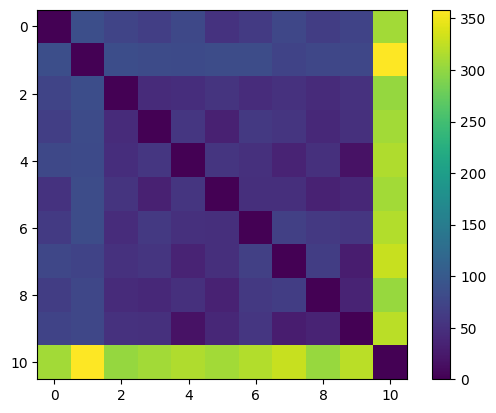

In [62]:
plt.imshow(distances_w1)
plt.colorbar()

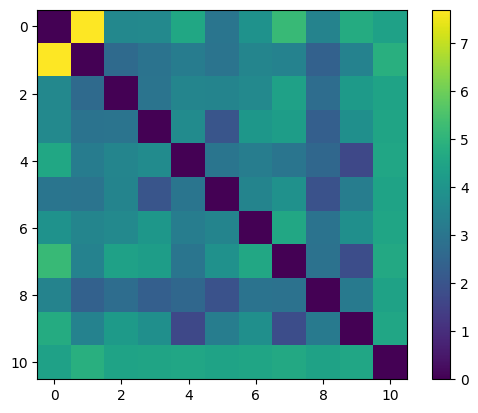

In [10]:
plt.imshow(distances_w2)
plt.colorbar()

In [57]:
plt.imshow(distances_sliced_w1)
plt.colorbar()

In [66]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.animation as animation


In [67]:
from probjax.distributions.divergences.wasserstein import _1d_wasserstein_without_cdf
from jax.scipy.optimize import minimize

In [69]:
mds_embedding1 = MDS(n_components=2, dissimilarity='precomputed', max_iter=50000, eps=1e-10, random_state=np.random.RandomState(0), n_init=500)
w1_embedding = mds_embedding1.fit_transform(distances_w1)
#w2_embedding = mds_embedding1.fit_transform(distances_w2)
sliced_w1_embedding = mds_embedding1.fit_transform(distances_sliced_w1)
sliced_w1_embedding_more_slices = mds_embedding1.fit_transform(distances_sliced_w1_more_slices)
max_sliced_w1_embedding = mds_embedding1.fit_transform(distances_sliced_w1_max_slices)

/root/miniconda3/envs/rvtorch/lib/python3.10/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(
/root/miniconda3/envs/rvtorch/lib/python3.10/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(
/root/miniconda3/envs/rvtorch/lib/python3.10/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(
/root/miniconda3/envs/rvtorch/lib/python3.10/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in ver

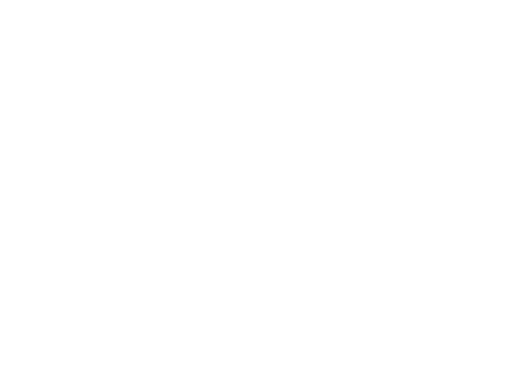

In [207]:
# mds_embedding1 = Isomap(n_components=2)
# w1_embedding = mds_embedding1.fit_transform(distances_w1)
# w2_embedding = mds_embedding1.fit_transform(distances_w2)
# sliced_w1_embedding = mds_embedding1.fit_transform(distances_sliced_w1)
# sliced_w1_embedding_more_slices = mds_embedding1.fit_transform(distances_sliced_w1_more_slices)

In [84]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.linalg import orthogonal_procrustes

def procrustes_alignment(embeddings_list):
    # Convert the list of embeddings to NumPy array
    embeddings_array = np.array(embeddings_list)

    # Get the number of embeddings and the dimensionality of each embedding
    num_embeddings, embedding_dim = embeddings_array.shape[:2]

    # Compute pairwise distances between embeddings
    pairwise_distances = cdist(embeddings_array[0], embeddings_array[1], 'euclidean')

    # Perform Procrustes alignment for each pair of embeddings
    aligned_embedding = embeddings_array[0]
    aligned_embedding = aligned_embedding - np.mean(aligned_embedding, axis=0, keepdims=True)
    aligned_embedding = aligned_embedding / np.std(aligned_embedding, axis=0, keepdims=True)
    aligned_embeddings = [aligned_embedding]

    for i in range(1, num_embeddings):
        aligned_embedding = embeddings_array[i]
        aligned_embedding = aligned_embedding - np.mean(aligned_embedding, axis=0, keepdims=True)
        aligned_embedding = aligned_embedding / np.std(aligned_embedding, axis=0, keepdims=True)
        transformation,_ = orthogonal_procrustes(embeddings_array[0],aligned_embedding)

        # Apply the transformation to align the current set of embeddings
        aligned_embedding = np.dot(aligned_embedding, transformation)
        # Normalize the aligned embedding to have unit norm
        
        aligned_embeddings.append(aligned_embedding)

    return aligned_embeddings

In [85]:
w1_embeddign_aligned, sliced_w1_embedding_aligned, sliced_w1_embedding_more_slices_aligned, max_sliced_w1_embedding_aligned = procrustes_alignment([w1_embedding, sliced_w1_embedding, sliced_w1_embedding_more_slices, max_sliced_w1_embedding])

#sliced_w1_embedding_more_slices_aligned, sliced_w1_embedding_aligned = procrustes_alignment([sliced_w1_embedding_more_slices_aligned, sliced_w1_embedding_aligned])

MovieWriter imagemagick unavailable; using Pillow instead.


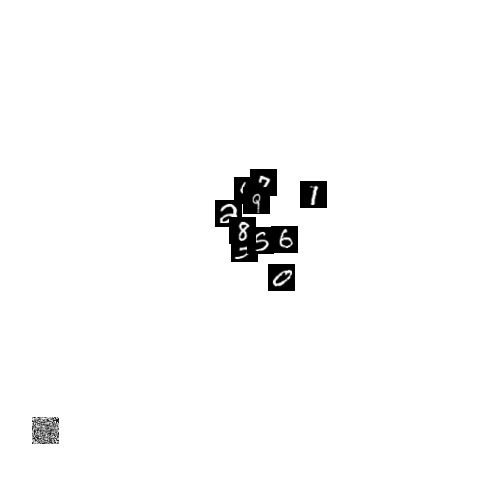

In [91]:
%matplotlib inline

# Function to update the plot for each frame
def update(frame):
    ax.clear()
    ax.set_xlim([-3.5, 3.5])
    ax.set_ylim([-3.5, 3.5])
    for i, (x, y) in enumerate(w1_embeddign_aligned):
        p = distributions[i] 
        samples = p.sample(jax.random.PRNGKey(frame + 1), (1,))
        ax.imshow(np.reshape(samples, (28, 28)), extent=[x-0.2, x+0.2, y-0.2, y+0.2], cmap='gray',  aspect='auto', zorder=0.1)
    plt.axis('off')
    
def init():
    ax.set_xlim([-0.75, 0.75])
    ax.set_ylim([-0.75, 0.75])
    for i, (x, y) in enumerate(w1_embeddign_aligned):
        p = distributions[i] 
        samples = p.sample(jax.random.PRNGKey(0), (1,))
        ax.imshow(np.reshape(samples, (28, 28)), extent=[x-0.2, x+0.2, y-0.2, y+0.2], cmap='gray',  aspect='auto', zorder=0.1)
    plt.axis('off')

# Create the figure and axis
fig, ax = plt.subplots(figsize=(6, 6))
plt.axis('off')

# # Create the animation
ani = animation.FuncAnimation(fig, update, frames=300, interval=500, init_func=init, blit=False, repeat=True)
ani.save('figures/w1_mnist.gif', writer='imagemagick', fps=4)
plt.show()


MovieWriter imagemagick unavailable; using Pillow instead.


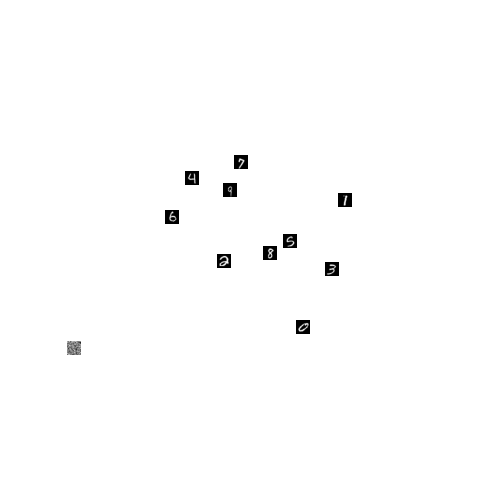

In [92]:
%matplotlib inline

# Function to update the plot for each frame
def update(frame):
    ax.clear()
    ax.set_xlim([-3.5, 3.5])
    ax.set_ylim([-3.5, 3.5])
    for i, (x, y) in enumerate(sliced_w1_embedding_aligned):
        p = distributions[i] 
        samples = p.sample(jax.random.PRNGKey(frame + 1), (1,))
        ax.imshow(np.reshape(samples, (28, 28)), extent=[x-0.1, x+0.1, y-0.1, y+0.1], cmap='gray',  aspect='auto', zorder=0.1)
    plt.axis('off')
    
def init():
    ax.set_xlim([-3.5, 3.5])
    ax.set_ylim([-3.5, 3.5])
    for i, (x, y) in enumerate(sliced_w1_embedding_aligned):
        p = distributions[i] 
        samples = p.sample(jax.random.PRNGKey(0), (1,))
        ax.imshow(np.reshape(samples, (28, 28)), extent=[x-0.1, x+0.1, y-0.1, y+0.1], cmap='gray',  aspect='auto', zorder=0.1)
    plt.axis('off')

# Create the figure and axis
fig, ax = plt.subplots(figsize=(6, 6))
plt.axis('off')

# # Create the animation
ani = animation.FuncAnimation(fig, update, frames=300, interval=500, init_func=init, blit=False, repeat=True)
ani.save('figures/w1_sliced.gif', writer='imagemagick', fps=4)
plt.show()


MovieWriter imagemagick unavailable; using Pillow instead.


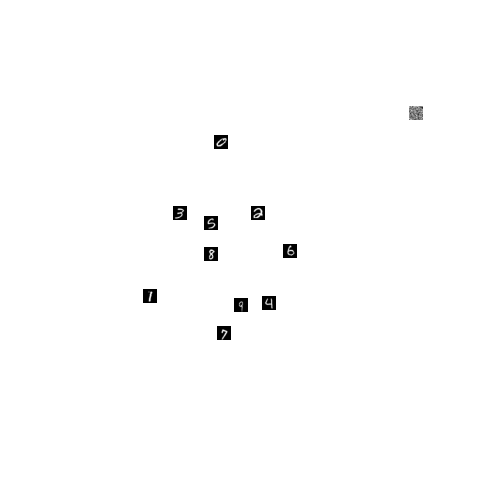

In [93]:
%matplotlib inline

# Function to update the plot for each frame
def update(frame):
    ax.clear()
    ax.set_xlim([-3.5, 3.5])
    ax.set_ylim([-3.5, 3.5])
    for i, (x, y) in enumerate(sliced_w1_embedding_more_slices_aligned):
        p = distributions[i] 
        samples = p.sample(jax.random.PRNGKey(frame + 1), (1,))
        ax.imshow(np.reshape(samples, (28, 28)), extent=[x-0.1, x+0.1, y-0.1, y+0.1], cmap='gray',  aspect='auto', zorder=0.1)
    plt.axis('off')
    
def init():
    ax.set_xlim([-3.5, 3.5])
    ax.set_ylim([-3.5, 3.5])
    for i, (x, y) in enumerate(sliced_w1_embedding_more_slices_aligned):
        p = distributions[i] 
        samples = p.sample(jax.random.PRNGKey(0), (1,))
        ax.imshow(np.reshape(samples, (28, 28)), extent=[x-0.1, x+0.1, y-0.1, y+0.1], cmap='gray',  aspect='auto', zorder=0.1)
    plt.axis('off')

# Create the figure and axis
fig, ax = plt.subplots(figsize=(6, 6))
plt.axis('off')

# # Create the animation
ani = animation.FuncAnimation(fig, update, frames=300, interval=500, init_func=init, blit=False, repeat=True)
ani.save('figures/w1_sliced_more_slices.gif', writer='imagemagick', fps=4)
plt.show()


MovieWriter imagemagick unavailable; using Pillow instead.


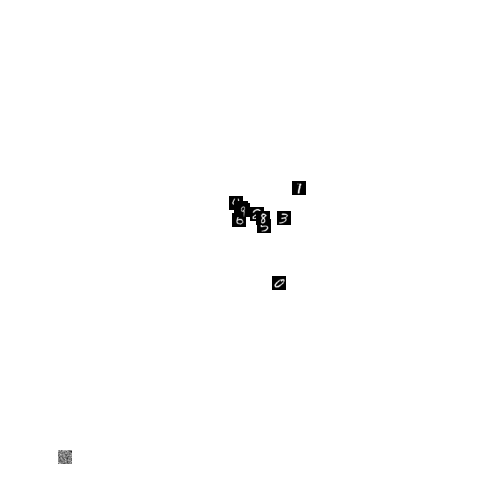

In [90]:
%matplotlib inline

# Function to update the plot for each frame
def update(frame):
    ax.clear()
    ax.set_xlim([-3.5, 3.5])
    ax.set_ylim([-3.5, 3.5])
    for i, (x, y) in enumerate(max_sliced_w1_embedding_aligned):
        p = distributions[i] 
        samples = p.sample(jax.random.PRNGKey(frame + 1), (1,))
        ax.imshow(np.reshape(samples, (28, 28)), extent=[x-0.1, x+0.1, y-0.1, y+0.1], cmap='gray',  aspect='auto', zorder=0.1)
    plt.axis('off')
    
def init():
    ax.set_xlim([-3.5, 3.5])
    ax.set_ylim([-3.5, 3.5])
    for i, (x, y) in enumerate(max_sliced_w1_embedding_aligned):
        p = distributions[i] 
        samples = p.sample(jax.random.PRNGKey(0), (1,))
        ax.imshow(np.reshape(samples, (28, 28)), extent=[x-0.1, x+0.1, y-0.1, y+0.1], cmap='gray',  aspect='auto', zorder=0.1)
    plt.axis('off')

# Create the figure and axis
fig, ax = plt.subplots(figsize=(6, 6))
plt.axis('off')

# # Create the animation
ani = animation.FuncAnimation(fig, update, frames=300, interval=500, init_func=init, blit=False, repeat=True)
ani.save('figures/w1_sliced_max_slices.gif', writer='imagemagick', fps=4)
plt.show()
